#### In this notebook we use CRU temperature data to explore long term climate trends in East Africa. We focus on Ethiopia Kenya Tanzania and Uganda and match the years to the DHS child survey years.  

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [3]:
sns.set_theme(style="whitegrid")
cru_temp_files = {
    "Ethiopia": "Ethiopia_CRU_temp_1901_2024.csv",
    "Kenya": "Kenya_CRU_temp_1901_2024.csv",
    "Tanzania": "Tanzania_CRU_temp_1901_2024.csv",
    "Uganda": "Uganda_CRU_temp_1901_2024.csv",
}
kr_files = [
    "Ethiopia_KR_1992_clean.csv",
    "Ethiopia_KR_1997_clean.csv",
    "Ethiopia_KR_2003_clean.csv",
    "Ethiopia_KR_2008_clean.csv",
    "Ethiopia_KR_2011_clean.csv",
    "Kenya_KR_89_clean.csv",
    "Kenya_KR_93_clean.csv",
    "Kenya_KR_98_clean.csv",
    "Kenya_KR_2003_clean.csv",
    "Kenya_KR_2009_clean.csv",
    "Kenya_KR_2014_clean.csv",
    "Kenya_KR_2022_clean.csv",
    "Tanzania_KR_92_clean.csv",
    "Tanzania_KR_96_clean.csv",
    "Tanzania_KR_99_clean.csv",
    "Tanzania_KR_2004_clean.csv",
    "Tanzania_KR_2010_clean.csv",
    "Tanzania_KR_2015_clean.csv",
    "Tanzania_KR_2022_clean.csv",
    "Uganda_KR_88_clean.csv",
    "Uganda_KR_95_clean.csv",
    "Uganda_KR_2001_clean.csv",
    "Uganda_KR_2006_clean.csv",
    "Uganda_KR_2011_clean.csv",
    "Uganda_KR_2016_clean.csv",
]


#### Here we read each CRU file and keep only year and annual mean temperature. We also make a simple anomaly relative to the period from 1981 to 2010.At the end we have one combined table called climate_all.

In [5]:
# list of KR child files I cleaned already
kr_files = [
    "Ethiopia_KR_1992_clean.csv",
    "Ethiopia_KR_1997_clean.csv",
    "Ethiopia_KR_2003_clean.csv",
    "Ethiopia_KR_2008_clean.csv",
    "Ethiopia_KR_2011_clean.csv",
    "Kenya_KR_89_clean.csv",
    "Kenya_KR_93_clean.csv",
    "Kenya_KR_98_clean.csv",
    "Kenya_KR_2003_clean.csv",
    "Kenya_KR_2009_clean.csv",
    "Kenya_KR_2014_clean.csv",
    "Kenya_KR_2022_clean.csv",
    "Tanzania_KR_92_clean.csv",
    "Tanzania_KR_96_clean.csv",
    "Tanzania_KR_99_clean.csv",
    "Tanzania_KR_2004_clean.csv",
    "Tanzania_KR_2010_clean.csv",
    "Tanzania_KR_2015_clean.csv",
    "Tanzania_KR_2022_clean.csv",
    "Uganda_KR_88_clean.csv",
    "Uganda_KR_95_clean.csv",
    "Uganda_KR_2001_clean.csv",
    "Uganda_KR_2006_clean.csv",
    "Uganda_KR_2011_clean.csv",
    "Uganda_KR_2016_clean.csv",
]



#### We loaded temperature anomaly data for Ethiopia, Kenya, Tanzania, and Uganda from 1901 to 2024. Each dataset was cleaned and standardized by subtracting the mean anomaly from the 1961–1990 baseline.This step aligns all four countries to a common reference point, making their trends directly comparable. The result is a unified dataset that lets us track how each country’s temperatures have shifted relative to historical norms. It helps us prepare and set up for  visualizing long-term warming patterns and spotting regional differences in climate change.

In [7]:
# Ethiopia climate data
ethiopia = pd.read_csv("Ethiopia_CRU_temp_1901_2024.csv")

ethiopia_temp = ethiopia[["YEAR", "ANN"]].copy()
ethiopia_temp = ethiopia_temp.rename(columns={"YEAR": "year", "ANN": "temp_ann"})
ethiopia_temp["country"] = "Ethiopia"

# baseline 1981–2010 for Ethiopia
eth_base = ethiopia_temp[(ethiopia_temp["year"] >= 1981) & (ethiopia_temp["year"] <= 2010)]
eth_base_mean = eth_base["temp_ann"].mean()

ethiopia_temp["temp_anom"] = ethiopia_temp["temp_ann"] - eth_base_mean


In [8]:
# Kenya climate data
kenya = pd.read_csv("Kenya_CRU_temp_1901_2024.csv")

kenya_temp = kenya[["YEAR", "ANN"]].copy()
kenya_temp = kenya_temp.rename(columns={"YEAR": "year", "ANN": "temp_ann"})
kenya_temp["country"] = "Kenya"

# baseline 1981–2010 for Kenya
ken_base = kenya_temp[(kenya_temp["year"] >= 1981) & (kenya_temp["year"] <= 2010)]
ken_base_mean = ken_base["temp_ann"].mean()

kenya_temp["temp_anom"] = kenya_temp["temp_ann"] - ken_base_mean


In [9]:
# Tanzania climate data
tanzania = pd.read_csv("Tanzania_CRU_temp_1901_2024.csv")

tanzania_temp = tanzania[["YEAR", "ANN"]].copy()
tanzania_temp = tanzania_temp.rename(columns={"YEAR": "year", "ANN": "temp_ann"})
tanzania_temp["country"] = "Tanzania"

# baseline 1981–2010 for Tanzania
tan_base = tanzania_temp[(tanzania_temp["year"] >= 1981) & (tanzania_temp["year"] <= 2010)]
tan_base_mean = tan_base["temp_ann"].mean()

tanzania_temp["temp_anom"] = tanzania_temp["temp_ann"] - tan_base_mean


In [10]:
# Uganda climate data
uganda = pd.read_csv("Uganda_CRU_temp_1901_2024.csv")

uganda_temp = uganda[["YEAR", "ANN"]].copy()
uganda_temp = uganda_temp.rename(columns={"YEAR": "year", "ANN": "temp_ann"})
uganda_temp["country"] = "Uganda"

# baseline 1981–2010 for Uganda
uga_base = uganda_temp[(uganda_temp["year"] >= 1981) & (uganda_temp["year"] <= 2010)]
uga_base_mean = uga_base["temp_ann"].mean()

uganda_temp["temp_anom"] = uganda_temp["temp_ann"] - uga_base_mean


In [11]:
# put all four countries into one table
climate_all = pd.concat([
    ethiopia_temp,
    kenya_temp,
    tanzania_temp,
    uganda_temp
])

climate_all.head()


,year,temp_ann,country,temp_anom
0,1901,22.7,Ethiopia,-0.256667
1,1902,22.6,Ethiopia,-0.356667
2,1903,22.7,Ethiopia,-0.256667
3,1904,22.5,Ethiopia,-0.456667
4,1905,22.6,Ethiopia,-0.356667


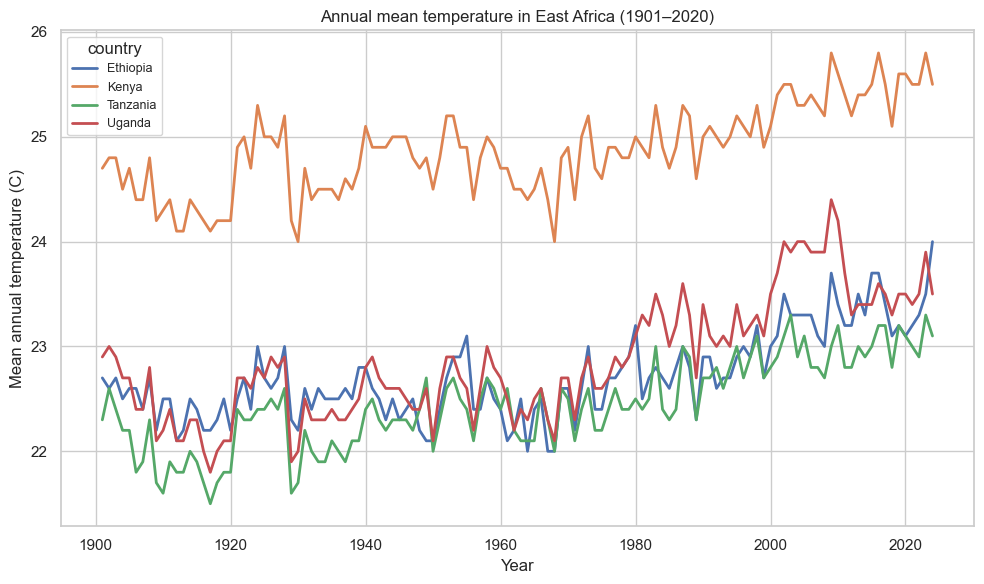

In [12]:
plt.figure(figsize=(10, 6))
for country in ["Ethiopia", "Kenya", "Tanzania", "Uganda"]:
    temp_country = climate_all[climate_all["country"] == country]
    plt.plot(temp_country["year"], temp_country["temp_ann"], label=country, linewidth=2)

plt.xlabel("Year")
plt.ylabel("Mean annual temperature (C)")
plt.title("Annual mean temperature in East Africa (1901–2020)")
plt.legend(title="country", fontsize=9)
plt.tight_layout()
plt.show()


#### We’re building a clean summary of how average temperatures have changed in East Africa from the 1950s to the early 2020s. For each country Ethiopia, Kenya, Tanzania, and Uganda, we calculate the mean annual temperature for every decade. This gives us a structured view of long-term climate trends, smoothing out year-to-year noise.The result is a tidy table that makes it easy to compare warming patterns across regions and time.It’s a solid foundation for plotting or deeper analysis on how climate has evolved over the last 70+ years

In [14]:
countries = ["Ethiopia", "Kenya", "Tanzania", "Uganda"]

# from the 1950s and go up to early 2020s
decade_ranges = [
    (1950, 1959, "1950s"),
    (1960, 1969, "1960s"),
    (1970, 1979, "1970s"),
    (1980, 1989, "1980s"),
    (1990, 1999, "1990s"),
    (2000, 2009, "2000s"),
    (2010, 2019, "2010s"),
    (2020, 2024, "early 2020s"),
]

decade_rows = []

for country in countries:
    # keep just this country
    temp_country = climate_all[climate_all["country"] == country]

    for start, end, label in decade_ranges:
        # limit to the decade
        tmp = temp_country[
            (temp_country["year"] >= start) & (temp_country["year"] <= end)
        ]
        avg_temp = tmp["temp_ann"].mean()

        decade_rows.append({
            "country": country,
            "decade_label": label,
            "decade_start": start,
            "decade_end": end,
            "temp_mean": avg_temp,
        })

decade_temp_table = pd.DataFrame(decade_rows)
decade_temp_table.head()


,country,decade_label,decade_start,decade_end,temp_mean
0,Ethiopia,1950s,1950,1959,22.61
1,Ethiopia,1960s,1960,1969,22.27
2,Ethiopia,1970s,1970,1979,22.63
3,Ethiopia,1980s,1980,1989,22.74
4,Ethiopia,1990s,1990,1999,22.85


#### Here we’re plotting how mean annual temperatures have shifted across Ethiopia, Kenya, Tanzania, and Uganda. We take the decade-level averages from the 1950s through the early 2020s and connect them with line plots. Each country’s trend is shown with markers, making it easy to see gradual warming or stability over time.The chart highlights long-term climate patterns, smoothing out short-term fluctuations and emphasizing regional differences. It’s a clear way to visualize how East Africa’s climate has evolved decade by decade.

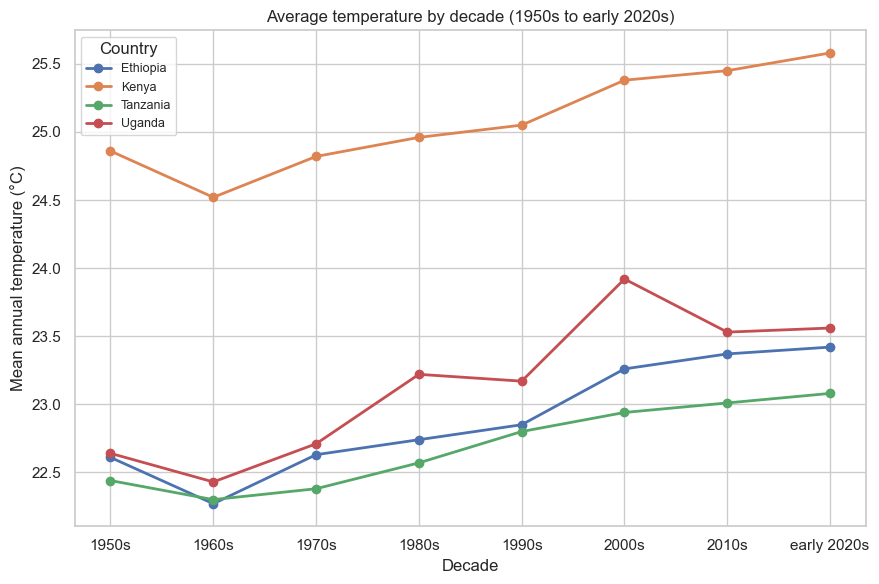

In [16]:
plt.figure(figsize=(9, 6))

for country in countries:
    tmp = decade_temp_table[decade_temp_table["country"] == country]
    tmp = tmp.sort_values("decade_start")

    plt.plot(
        tmp["decade_label"],
        tmp["temp_mean"],
        marker="o",
        linewidth=2,
        label=country,
    )

plt.xlabel("Decade")
plt.ylabel("Mean annual temperature (°C)")
plt.title("Average temperature by decade (1950s to early 2020s)")
plt.legend(title="Country", fontsize=9)
plt.tight_layout()
plt.show()


##### We’re looking at how average annual temperatures have shifted across East African countries over time.To keep things clean, we split the data into two periods: one from 1950 to 1980, and another from 1990 to 2020.Then we use boxplots to compare the temperature distributions by country, highlighting changes between the earlier and more recent decades.The color palette is chosen to be colorblind-friendly, and the layout makes it easy to spot trends.This helps us see which regions have warmed the most and how consistent those changes have been.


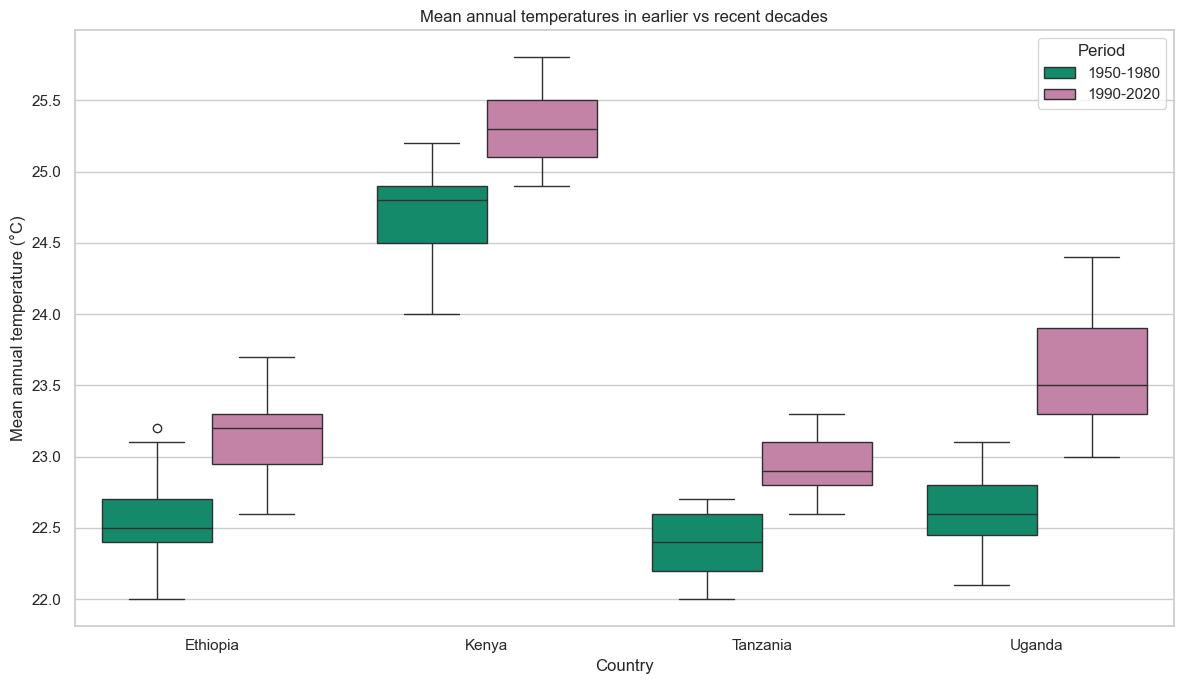

In [18]:
early = climate_all[(climate_all["year"] >= 1950) & (climate_all["year"] <= 1980)].copy()
late = climate_all[(climate_all["year"] >= 1990) & (climate_all["year"] <= 2020)].copy()

early["period"] = "1950-1980"
late["period"] = "1990-2020"

# put the two pieces together
temp_period = pd.concat([early, late], ignore_index=True)

# colorblind friendly palette
period_colors = {
    "1950-1980": "#009E73",   # teal
    "1990-2020": "#CC79A7",   # magenta
}

plt.figure(figsize=(12, 7))
sns.boxplot(
    data=temp_period,
    x="country",
    y="temp_ann",
    hue="period",
    palette=period_colors
)

plt.xlabel("Country")
plt.ylabel("Mean annual temperature (°C)")
plt.title("Mean annual temperatures in earlier vs recent decades")
plt.legend(title="Period")
plt.tight_layout()
plt.show()


##### Here we split the years into two periods 1961–1990 and 1991–2020 to see how seasonal patterns have shifted. For each country, we calculate the average temperature for every month across both periods.The result is a tidy dataset monthly_climate that shows side-by-side comparisons of monthly means. This setup makes it easy to visualize how warming trends play out across different seasons and regions.

In [20]:
# we want the monthly columns from the CRU file
month_cols = ["JAN","FEB","MAR","APR","MAY","JUN",
              "JUL","AUG","SEP","OCT","NOV","DEC"]

monthly_list = []

for country, fname in cru_temp_files.items():
    df = pd.read_csv(fname)
    
    # keep only years where we want to compare
    df = df[(df["YEAR"] >= 1961) & (df["YEAR"] <= 2020)].copy()
    
    # simple early / late period label
    df["period"] = "1961–1990"
    df.loc[df["YEAR"] >= 1991, "period"] = "1991–2020"
    
    # now we average each month in each period
    for m in month_cols:
        tmp = df.groupby("period")[m].mean().reset_index()
        tmp["country"] = country
        tmp["month"] = m
        tmp = tmp[["country", "period", "month", m]]
        tmp = tmp.rename(columns={m: "temp_month_mean"})
        monthly_list.append(tmp)

monthly_climate = pd.concat(monthly_list, ignore_index=True)

monthly_climate.head()


,country,period,month,temp_month_mean
0,Ethiopia,1961–1990,JAN,21.476667
1,Ethiopia,1991–2020,JAN,21.943333
2,Ethiopia,1961–1990,FEB,22.553333
3,Ethiopia,1991–2020,FEB,23.250000
4,Ethiopia,1961–1990,MAR,23.720000


#### In this step, we’re comparing monthly temperature averages across two broad periods: 1901–1960 and 1961–2024. For each country, we calculate the mean temperature for every month and then plot them side by side. The result is a set of line charts (one per country) that show how seasonal cycles have shifted over the last century. By ordering months in calendar sequence, we can clearly see changes in warming trends across different seasons.  This visualization highlights both long-term climate shifts and regional differences in seasonal temperature patterns.


In [22]:
month_cols = ["JAN","FEB","MAR","APR","MAY","JUN",
              "JUL","AUG","SEP","OCT","NOV","DEC"]

monthly_list = []

for country, fname in cru_temp_files.items():
    df = pd.read_csv(fname)
    
    # keep the full CRU range just in case
    df = df[(df["YEAR"] >= 1901) & (df["YEAR"] <= 2024)]
    
    # make a simple early vs late period
    df["period"] = "1901–1960"
    df.loc[df["YEAR"] >= 1961, "period"] = "1961–2024"
    
    # loop over months and get average temp in each period
    for col in month_cols:
        tmp = df[["period", col]].groupby("period").mean().reset_index()
        tmp["country"] = country
        tmp["month"] = col
        tmp = tmp.rename(columns={col: "temp_month_mean"})
        monthly_list.append(tmp)

monthly_climate = pd.concat(monthly_list)

In [23]:
# we add a month number so we can sort months properly
month_labels = ["JAN","FEB","MAR","APR","MAY","JUN",
                "JUL","AUG","SEP","OCT","NOV","DEC"]

monthly_climate["month_num"] = 0

for i in range(len(month_labels)):
    m = month_labels[i]
    monthly_climate.loc[monthly_climate["month"] == m, "month_num"] = i


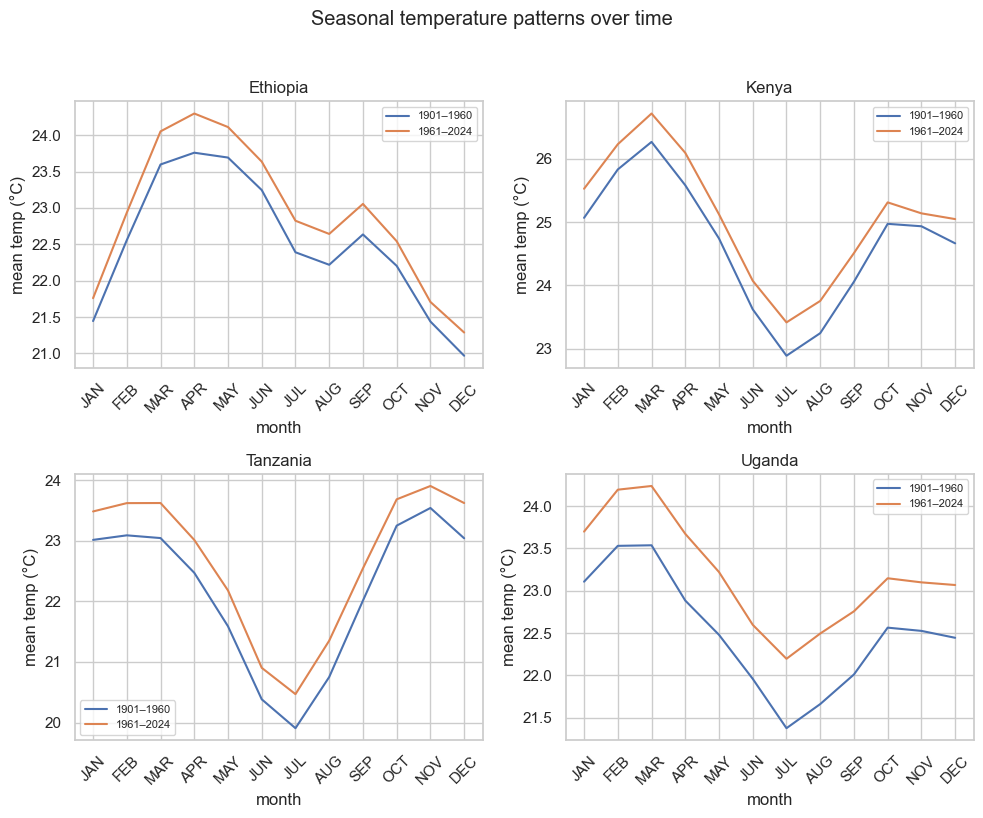

In [24]:
# order months so they plot in calendar order
month_labels = ["JAN","FEB","MAR","APR","MAY","JUN",
                "JUL","AUG","SEP","OCT","NOV","DEC"]

countries = monthly_climate["country"].unique()

plt.figure(figsize=(10, 8))

for i, country in enumerate(countries):
    # we want a 2x2 grid of plots (one per country)
    plt.subplot(2, 2, i + 1)
    
    # keep only rows from this country
    sub = monthly_climate[monthly_climate["country"] == country]
    
    # split by period and sort by month number
    early = sub[sub["period"] == "1901–1960"].sort_values("month_num")
    late  = sub[sub["period"] == "1961–2024"].sort_values("month_num")
    
    # simple line plots, no markers
    plt.plot(early["month_num"], early["temp_month_mean"])
    plt.plot(late["month_num"],  late["temp_month_mean"])
    
    plt.title(country)
    plt.xlabel("month")
    plt.ylabel("mean temp (°C)")
    plt.xticks(range(12), month_labels, rotation=45)
    plt.legend(["1901–1960", "1961–2024"], fontsize=8)

plt.suptitle("Seasonal temperature patterns over time", y=1.02)
plt.tight_layout()
plt.show()

#### Here we’re breaking down over a century of precipitation data into four meaningful climate periods.  We label each year from 1901 to 2020 into blocks like 1901 to 1930 or 1991 to 2020 to make patterns easier to spot.Then we plot boxplots by country, showing how annual rainfall has shifted across these time slices.The colors are chosen to be colorblind-friendly, and the layout keeps things clean and readable. This gives us a clear visual comparison of how precipitation has varied over time and across regions.

In [26]:
def label_period_4(y):
    if y <= 1930:
        return "1901 to 1930"
    elif y <= 1960:
        return "1931 to 1960"
    elif y <= 1990:
        return "1961 to 1990"
    else:
        return "1991 to 2020"
precip_per_period = precip_all[(precip_all["year"] >= 1901) & (precip_all["year"] <= 2020)].copy()
precip_per_period["period_4"] = precip_per_period["year"].apply(label_period_4)



NameError: name 'precip_all' is not defined

In [ ]:
# choose four colorblind-friendly colors
rain4_colors = {
    "1901 to 1930": "#0072B2",  # blue
    "1931 to 1960": "#009E73",  # green
    "1961 to 1990": "#D55E00",  # orange
    "1991 to 2020": "#CC79A7",  # magenta
}

plt.figure(figsize=(10, 6))

# boxplots: x = country, color = period
sns.boxplot(
    data=precip_per_period,
    x="country",
    y="precip_ann",
    hue="period_4",
    palette=rain4_colors
)

plt.xlabel("Country")
plt.ylabel("Mean annual precipitation (mm)")
plt.title("Mean annual precipitation across four climate periods")
plt.legend(title="Period")
plt.tight_layout()
plt.show()
